In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [37]:
coffee=pd.read_csv(r"C:\Users\athar\Downloads\archive (33)\synthetic_coffee_health_10000.csv")

In [38]:
coffee.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [39]:
coffee.tail()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0
9999,10000,42,Female,Brazil,2.9,277.5,6.4,Good,28.1,72,Low,9.8,NaN,Student,1,0


In [40]:
coffee.shape

(10000, 16)

In [41]:
coffee.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [42]:
coffee.isnull().sum()

ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

In [43]:
# filling the unknown nan with no issues in health issues
coffee['Health_Issues']=coffee['Health_Issues'].fillna('No issues')

In [44]:
coffee.dtypes

ID                           int64
Age                          int64
Gender                      object
Country                     object
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality               object
BMI                        float64
Heart_Rate                   int64
Stress_Level                object
Physical_Activity_Hours    float64
Health_Issues               object
Occupation                  object
Smoking                      int64
Alcohol_Consumption          int64
dtype: object

In [45]:
coffee.isnull().sum()

ID                         0
Age                        0
Gender                     0
Country                    0
Coffee_Intake              0
Caffeine_mg                0
Sleep_Hours                0
Sleep_Quality              0
BMI                        0
Heart_Rate                 0
Stress_Level               0
Physical_Activity_Hours    0
Health_Issues              0
Occupation                 0
Smoking                    0
Alcohol_Consumption        0
dtype: int64

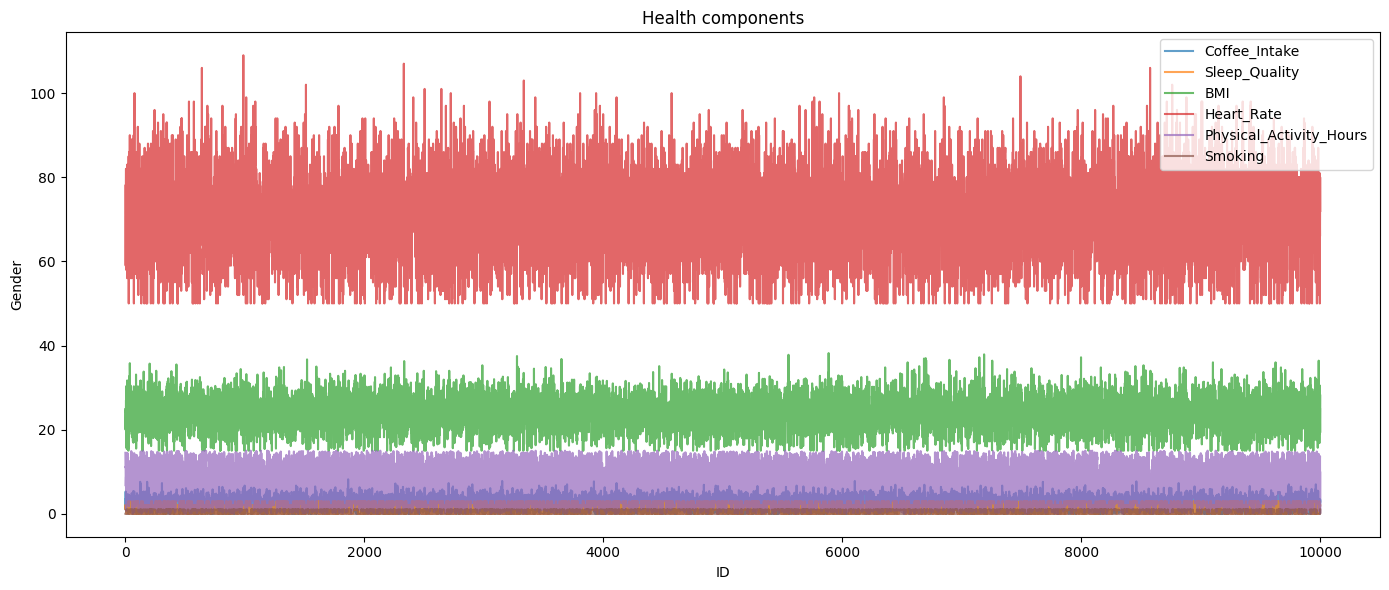

In [72]:
plt.figure(figsize=(14, 6))
for col in ['Coffee_Intake', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking']:
    plt.plot(coffee['ID'], coffee[col], label=col, alpha=0.7)

plt.title('Health components')
plt.xlabel('ID')
plt.ylabel('Gender')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Label Encoding
le =LabelEncoder()
for col in coffee.columns:
    if coffee[col].dtype == 'object':
        coffee[col] = LabelEncoder().fit_transform(coffee[col])

In [47]:
coffee.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,1,7,3.5,328.1,7.5,2,24.9,78,1,14.5,2,2,0,0
1,2,33,1,7,1.0,94.1,6.2,2,20.0,67,1,11.0,2,3,0,0
2,3,42,1,2,5.3,503.7,5.9,1,22.7,59,2,11.2,0,1,0,0
3,4,53,1,7,2.6,249.2,7.3,2,24.7,71,1,6.6,0,2,0,0
4,5,32,0,15,3.1,298.0,5.3,1,24.1,76,2,8.5,0,4,0,1


In [48]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Suppose your original DataFrame is still available as df
X = coffee.drop(columns=['ID', 'Health_Issues'])   # features
y = coffee['Health_Issues']                        # target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Keep DataFrame with column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [49]:
from sklearn.model_selection import train_test_split

In [51]:
print(X_scaled)

           Age    Gender   Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0     0.452574  0.879605 -0.429771       0.683207     0.651138     0.706861   
1    -0.174645  0.879605 -0.429771      -1.040723    -1.047691    -0.356974   
2     0.631779  0.879605 -1.300882       1.924437     1.925986    -0.602474   
3     1.617409  0.879605 -0.429771       0.062592     0.078328     0.543194   
4    -0.264247 -0.962500  0.964006       0.407378     0.432613    -1.093475   
...        ...       ...       ...            ...          ...          ...   
9995  1.348601 -0.962500  0.092895      -0.282194    -0.280314    -0.520641   
9996 -1.518685 -0.962500  1.486672       0.614250     0.586524    -0.684308   
9997 -0.801863  0.879605 -0.952437      -0.626979    -0.617176     0.379527   
9998  0.452574 -0.962500 -0.778215       0.614250     0.643878     0.297694   
9999  0.631779 -0.962500 -1.300882       0.269464     0.283784    -0.193307   

      Sleep_Quality       BMI  Heart_Rate  Stress_L

In [54]:
print(y)

0       2
1       2
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    2
9998    2
9999    2
Name: Health_Issues, Length: 10000, dtype: int64


In [55]:
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=4)

In [56]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [57]:
model=RandomForestClassifier()

In [58]:
model.fit(X_train,Y_train)

RandomForestClassifier()

In [60]:
from sklearn.metrics import accuracy_score,r2_score

In [63]:
y_pred=model.predict(X_test)

In [65]:
training_data_accuracy = accuracy_score(y_pred,Y_test)

In [66]:
print(training_data_accuracy)

0.9975


In [67]:
r2score=r2_score(y_pred,Y_test)

In [68]:
print(r2_score)

<function r2_score at 0x000002182C8C37E0>


In [77]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [80]:
models= {
    'RandomForestClaasifier':RandomForestClassifier(),
    'Logisticregression':LogisticRegression(),
    'Kneighbors':KNeighborsClassifier(),
    'Svc':SVC(),
    'Decision tree':DecisionTreeClassifier(),}

# Train, predict, evaluate
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    score = r2_score(Y_test, y_pred) * 100  # Convert R² score to percentage
    accuracy_scores[name] = round(score, 2)

In [81]:
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    score = r2_score(Y_test, y_pred) * 100  # Convert R² score to percentage
    accuracy_scores[name] = round(score, 2)

In [82]:
# Display results
print("Model Accuracies (%):")
for model, acc in accuracy_scores.items():
    print(f"{model}: {acc}%")

Model Accuracies (%):
RandomForestClaasifier: 98.44%
Logisticregression: 45.26%
Kneighbors: 63.23%
Svc: 84.65%
Decision tree: 99.78%


In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score

C:\Users\athar\AppData\Local\Temp\ipykernel_13164\2109174355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')


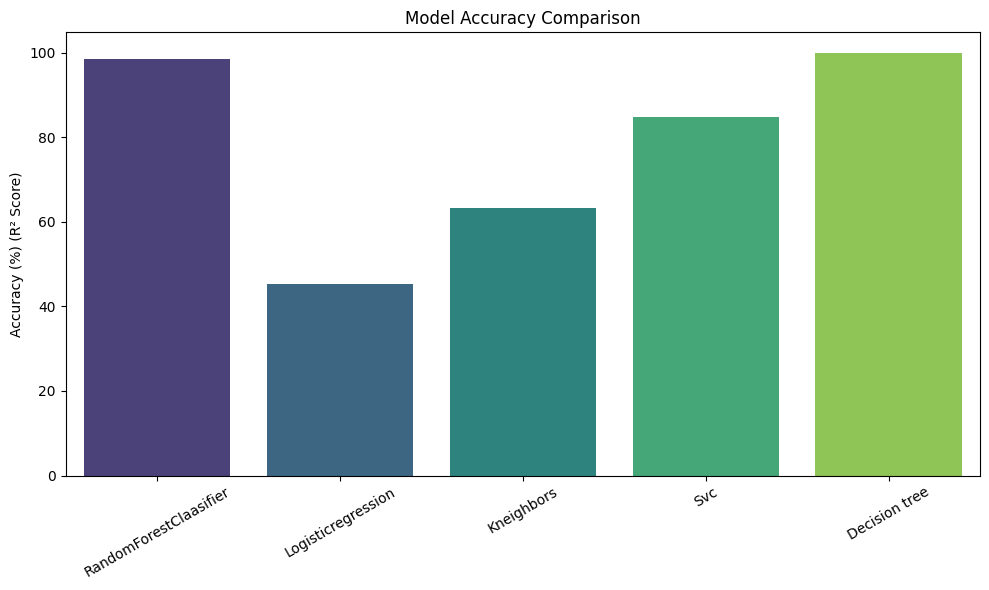

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette='viridis')
plt.xticks(rotation=30)
plt.ylabel('Accuracy (%) (R² Score)')
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()